# Imports and Initialization/Instantiations

## Imports

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

## Initialization/Instantiation

In [195]:
file = "Data Gathered.csv"

ogDf = pd.read_csv(file)
df = ogDf.copy()

## Constants

In [196]:
SESSION_PERIODS = {
    "Early Morning": (0, 6),    # 12:00 AM - 05:59 AM
    "Morning": (6, 12),         # 06:00 AM - 11:59 AM
    "Afternoon": (12, 18),      # 12:00 PM - 05:59 PM
    "Evening": (18, 24)         # 06:00 PM - 11:59 PM
}
"""
Defines the slicing of the day. The dict is defined as:
- key: The session name/classification of the time.
- value: A 2-value tuple consisting of the start (inclusive) and end (exclusive) time of the session.

The current slice goes as follows:

Session       | Start    | End     
:------------ | :------- | :-------
Early Morning | 12:00 AM | 05:59 AM
Morning       | 06:00 AM | 11:59 AM
Early Morning | 12:00 PM | 05:59 PM
Early Morning | 06:00 PM | 11:59 PM
"""

# Mug Related - For the coffee and tea or basically, the caffeine.
MUG_INNER_DIAMETER_CM = 8.6
MUG_INNER_HEIGHT_CM = 11.5
MUG_VOLUME_ML = round(3.14159 * (MUG_INNER_DIAMETER_CM / 2) ** 2 * MUG_INNER_HEIGHT_CM, 2)  # ~668.4 mL
FILL_RATE = 0.875
MUG_FILL_ML = round(MUG_VOLUME_ML * FILL_RATE, 2)  # ~584.9 mL

# END
None

## Available Methods

In [197]:
# classify_session_period
def classify_session_period(timing: str) -> str|float:
    """
    Classifies the timing of the work time whether it falls under one of the present categories.
    Uses the `SESSION_PERIODS` dictionary for identifying the classification of the time.

    :param str timing: The start time of the work session.

    :return classification: The classification of the start time. If it does not match any, it returns `N/A`.
    :rtype: str|float
    """
    
    if pd.isna(timing):
        return np.nan

    # Extract start time (before the ' - ')
    start_str = timing.split(' - ')[0].strip()
    start_time = pd.to_datetime(start_str, format='%I:%M %p')
    hour = start_time.hour

    for classification in SESSION_PERIODS:
        start, end = SESSION_PERIODS[classification]
        
        if start <= hour < end:
            return classification
    return np.nan

# END

# Data Understanding

Checking the dataframe's [shape](#shape), [data types (dtypes)](#data-types), and [missing-values](#missing-values).

In [198]:
ogDf.head()

,Date,Day_Of_Week,Mod_Development_Hours,Programming_Screen_Time,Total_Screen_Time,Coffee_Intake,Tea_Intake,Git_Commits,Tasks_Completed,Sleep_Duration,Mood_Rating,Energy_Level,Focus_Quality,Motivation_Level,Work_Session_Count,Work_Session_Timing,Primary_Focus_Area,Other_Deadlines_Present
0,"March 01, 2026",Sunday,2.000,0.0,17.267,3,0,0,2,4.667,4,3,4,3,1,10:03 PM - 11:59 PM,Modeling / Animation,1
1,"March 02, 2026",Monday,5.883,0.0,11.816,0,0,0,0,5.850,3,3,3,2,1,12:00 AM - 5:53 AM,Modeling / Animation,2
2,"March 03, 2026",Tuesday,0.000,0.0,11.683,0,0,0,0,8.983,3,3,4,3,0,NaN,NaN,2
3,"March 04, 2026",Wednesday,0.000,0.0,16.733,1,0,0,0,3.583,3,2,2,4,0,NaN,NaN,2
4,"March 05, 2026",Thursday,0.000,0.0,9.666,0,0,0,0,1.700,2,1,1,2,0,NaN,NaN,1


## Shape

In [199]:
print(f"[SHAPE]: {ogDf.shape}")
print(f"\t- {ogDf.shape[0]} days of data")
print(f"\t- {ogDf.shape[1]} variables")

[SHAPE]: (70, 18)
	- 70 days of data
	- 18 variables


## Data Types

In [200]:
print("Data Types:")
print(ogDf.dtypes)

Data Types:
Date                        object
Day_Of_Week                 object
Mod_Development_Hours      float64
Programming_Screen_Time    float64
Total_Screen_Time          float64
Coffee_Intake                int64
Tea_Intake                   int64
Git_Commits                  int64
Tasks_Completed              int64
Sleep_Duration             float64
Mood_Rating                  int64
Energy_Level                 int64
Focus_Quality                int64
Motivation_Level             int64
Work_Session_Count           int64
Work_Session_Timing         object
Primary_Focus_Area          object
Other_Deadlines_Present      int64
dtype: object


## Missing Values

In [201]:
missing = ogDf.isnull().sum()

print("Missing Values:")
print(missing[missing > 0])

Missing Values:
Work_Session_Timing    38
Primary_Focus_Area     38
dtype: int64


## Interpretation

- `Work_Session_Timing` and `Primary_Focus_Area` have 38 missing values each.
- These correspond to days where `Mod_Dev_Hours = 0` (no session occurred).
- Missing values are valid and expected, not data quality issues.

In [202]:
active_days = (ogDf['Mod_Development_Hours'] > 0).sum()
zero_days = (ogDf['Mod_Development_Hours'] == 0).sum()

print(f"Active mod dev days:   {active_days}/{len(ogDf)} ({active_days/len(ogDf)*100:.1f}%)")
print(f"Zero mod dev days:     {zero_days}/{len(ogDf)} ({zero_days/len(ogDf)*100:.1f}%)")

Active mod dev days:   32/70 (45.7%)
Zero mod dev days:     38/70 (54.3%)


### Descriptive Stats

#### Full Dataset

Checks the full dataset, including none-working days.

In [203]:
key_cols = [
    'Mod_Development_Hours', 'Coffee_Intake', 'Tea_Intake',
    'Sleep_Duration', 'Mood_Rating', 'Energy_Level',
    'Focus_Quality', 'Motivation_Level', 'Git_Commits',
    'Tasks_Completed', 'Other_Deadlines_Present'
]

print("=== Descriptive Stats (All 70 Days) ===\n")
print(df[key_cols].describe().round(3))

=== Descriptive Stats (All 70 Days) ===



       Mod_Development_Hours  Coffee_Intake  Tea_Intake  Sleep_Duration  \
count                 70.000         70.000      70.000          70.000   
mean                   2.604          1.786       0.043           4.935   
std                    3.629          1.641       0.266           2.912   
min                    0.000          0.000       0.000           0.000   
25%                    0.000          0.000       0.000           3.338   
50%                    0.000          1.500       0.000           4.858   
75%                    4.679          3.000       0.000           6.613   
max                   12.400          6.000       2.000          12.117   

       Mood_Rating  Energy_Level  Focus_Quality  Motivation_Level  \
count       70.000        70.000         70.000            70.000   
mean         3.086         2.557          2.500             2.757   
std          1.087         1.030          1.046             1.135   
min          1.000         1.000          1.000 

#### Active Days

Then check only the active days since the "zero days" skews the mean for `Mod_Dev_Hours`.

In [204]:
active_df = df[df['Mod_Development_Hours'] > 0]

print("=== Descriptive Stats (Active Days Only, n=32) ===\n")
print(active_df[key_cols].describe().round(3))

=== Descriptive Stats (Active Days Only, n=32) ===

       Mod_Development_Hours  Coffee_Intake  Tea_Intake  Sleep_Duration  \
count                 32.000         32.000        32.0          32.000   
mean                   5.695          2.438         0.0           4.004   
std                    3.337          1.645         0.0           2.886   
min                    0.150          0.000         0.0           0.000   
25%                    3.038          1.000         0.0           0.998   
50%                    4.983          2.000         0.0           4.542   
75%                    7.342          3.250         0.0           5.983   
max                   12.400          6.000         0.0           8.917   

       Mood_Rating  Energy_Level  Focus_Quality  Motivation_Level  \
count       32.000        32.000         32.000            32.000   
mean         3.125         2.594          2.875             3.000   
std          1.289         1.160          1.185             1.368

# Data Cleaning & Preprocessing

From hereforth, the `df` variable will be used. `ogDf` is for retaining the original dataframe for possible later use.

### Date Parsing

So dates are shown properly.

In [205]:
df['Date'] = pd.to_datetime(df['Date'])

print("[DATE RANGE]")
print(f"\tStart: {df['Date'].min().strftime('%B %d, %Y')}")
print(f"\tEnd:   {df['Date'].max().strftime('%B %d, %Y')}")
print(f"\tSpan:  {(df['Date'].max() - df['Date'].min()).days + 1} days")

[DATE RANGE]
	Start: March 01, 2026
	End:   May 09, 2026
	Span:  70 days


### Caffeine Column

Combines the coffee and tea intakes for total caffeinated drinks for the day.

In [206]:
df['Total_Caffeine'] = df['Coffee_Intake'] + df['Tea_Intake']

print("Total Caffeine stats:")
print(df['Total_Caffeine'].describe().round(3))

Total Caffeine stats:
count    70.000
mean      1.829
std       1.642
min       0.000
25%       0.000
50%       2.000
75%       3.000
max       6.000
Name: Total_Caffeine, dtype: float64


In [207]:
df['Total_Caffeine_mL'] = df['Total_Caffeine'] * MUG_FILL_ML

## Session Period Distribution

Lays out the distribution of the session periods throughout the active days.

In [208]:
df['Session_Period'] = df['Work_Session_Timing'].apply(classify_session_period)

print("Session Period Distribution (active days only):")
print(df['Session_Period'].value_counts())

Session Period Distribution (active days only):
Session_Period
Early Morning    23
Evening           5
Morning           4
Name: count, dtype: int64


## Night Session Breakdown

Identify how much of the active days are considered a "Night Session".

In [209]:
df['Is_Night_Session'] = df['Session_Period'].isin(['Evening', 'Early Morning'])

active_df = df[df['Mod_Development_Hours'] > 0]

print("\nNight Session breakdown (active days only):")
print(active_df['Is_Night_Session'].value_counts())
print(f"\nNight sessions: {active_df['Is_Night_Session'].sum()}/{len(active_df)} active days ({(active_df['Is_Night_Session'].sum() / len(active_df)):.2%})")


Night Session breakdown (active days only):
Is_Night_Session
True     28
False     4
Name: count, dtype: int64

Night sessions: 28/32 active days (87.50%)


## Fill NaNs

Fills in the `NaN` cells for easier handling down the line.

In [210]:
df['Primary_Focus_Area'] = df['Primary_Focus_Area'].fillna('No Session')
df['Work_Session_Timing'] = df['Work_Session_Timing'].fillna('No Session')

print("NaNs after fill:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("None remaining!" if df.isnull().sum().sum() == 0 else "")

NaNs after fill:
Session_Period    38
dtype: int64



## Verify Cleaned Dataset

In [211]:
print("=== CLEANED DATASET SUMMARY ===")
print(f"Shape:          {df.shape}")
print(f"Date range:     {df['Date'].min().strftime('%b %d, %Y')} to {df['Date'].max().strftime('%b %d, %Y')}")
print(f"Active days:    {(df['Mod_Development_Hours'] > 0).sum()}/70")
print(f"Night sessions: {df['Is_Night_Session'].sum()}/32 active days")
print(f"New columns:    Total_Caffeine, Total_Caffeine_mL, Session_Period, Is_Night_Session")
print(f"\nAll columns:")
print(df.columns.tolist())

=== CLEANED DATASET SUMMARY ===
Shape:          (70, 22)
Date range:     Mar 01, 2026 to May 09, 2026
Active days:    32/70
Night sessions: 28/32 active days
New columns:    Total_Caffeine, Total_Caffeine_mL, Session_Period, Is_Night_Session

All columns:
['Date', 'Day_Of_Week', 'Mod_Development_Hours', 'Programming_Screen_Time', 'Total_Screen_Time', 'Coffee_Intake', 'Tea_Intake', 'Git_Commits', 'Tasks_Completed', 'Sleep_Duration', 'Mood_Rating', 'Energy_Level', 'Focus_Quality', 'Motivation_Level', 'Work_Session_Count', 'Work_Session_Timing', 'Primary_Focus_Area', 'Other_Deadlines_Present', 'Total_Caffeine', 'Total_Caffeine_mL', 'Session_Period', 'Is_Night_Session']


# Exploratory Data Analysis

## Mod Development Hours

### Distribution

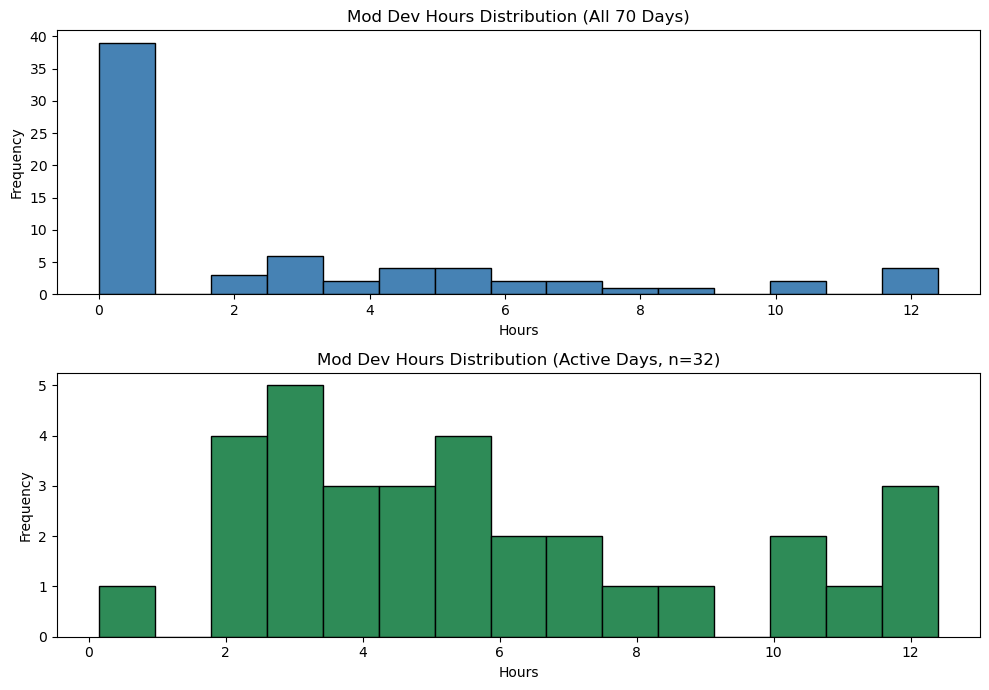

All days mean:    2.604 hrs
Active days mean: 5.695 hrs
Active days max:  12.400 hrs


In [212]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# Left: Histogram — all 70 days
axes[0].hist(df['Mod_Development_Hours'], bins=15, color='steelblue', edgecolor='black')
axes[0].set_title('Mod Dev Hours Distribution (All 70 Days)')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Frequency')

# Right: Histogram — active days only
active_df = df[df['Mod_Development_Hours'] > 0]
axes[1].hist(active_df['Mod_Development_Hours'], bins=15, color='seagreen', edgecolor='black')
axes[1].set_title('Mod Dev Hours Distribution (Active Days, n=32)')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"All days mean:    {df['Mod_Development_Hours'].mean():.3f} hrs")
print(f"Active days mean: {active_df['Mod_Development_Hours'].mean():.3f} hrs")
print(f"Active days max:  {active_df['Mod_Development_Hours'].max():.3f} hrs")

### Plot

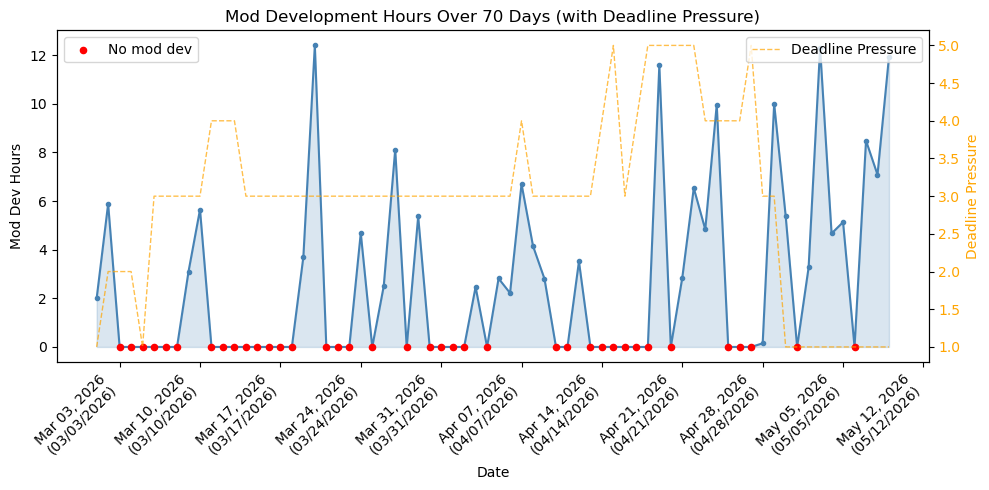

In [213]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['Date'], df['Mod_Development_Hours'], color='steelblue', linewidth=1.5, marker='o', markersize=3)
ax.fill_between(df['Date'], df['Mod_Development_Hours'], alpha=0.2, color='steelblue')

# Highlight zero days
zero_days_df = df[df['Mod_Development_Hours'] == 0]
ax.scatter(zero_days_df['Date'], zero_days_df['Mod_Development_Hours'],
           color='red', zorder=5, s=20, label='No mod dev')

# Deadline pressure overlay — secondary axis
ax2 = ax.twinx()
ax2.plot(df['Date'], df['Other_Deadlines_Present'], color='orange',
         linewidth=1, linestyle='--', alpha=0.7, label='Deadline Pressure')
ax2.set_ylabel('Deadline Pressure', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

ax.set_title('Mod Development Hours Over 70 Days (with Deadline Pressure)')
ax.set_xlabel('Date')
ax.set_ylabel('Mod Dev Hours')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y\n(%m/%d/%Y)'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Session Period

### Distribution

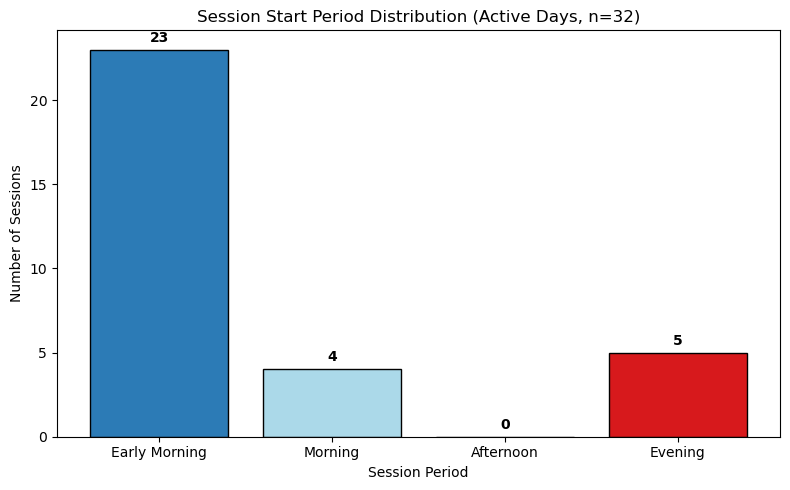

Session Period Counts:
Session_Period
Early Morning    23
Morning           4
Afternoon         0
Evening           5
Name: count, dtype: int64

Night sessions (Evening + Early Morning): 28/32
Day sessions (Morning + Afternoon):       4/32


In [214]:
active_df = df[df['Mod_Development_Hours'] > 0]

period_order = ['Early Morning', 'Morning', 'Afternoon', 'Evening']
period_counts = active_df['Session_Period'].value_counts().reindex(period_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(period_counts.index, period_counts.values,
              color=['#2c7bb6', '#abd9e9', '#fdae61', '#d7191c'],
              edgecolor='black')

# Add count labels on top of each bar
for bar, count in zip(bars, period_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(count), ha='center', va='bottom', fontweight='bold')

ax.set_title('Session Start Period Distribution (Active Days, n=32)')
ax.set_xlabel('Session Period')
ax.set_ylabel('Number of Sessions')

plt.tight_layout()
plt.show()

print("Session Period Counts:")
print(period_counts)
print(f"\nNight sessions (Evening + Early Morning): {period_counts['Evening'] + period_counts['Early Morning']}/{len(active_df)}")
print(f"Day sessions (Morning + Afternoon):       {period_counts['Morning'] + period_counts['Afternoon']}/{len(active_df)}")

## Deadline Pressure

### Distribution

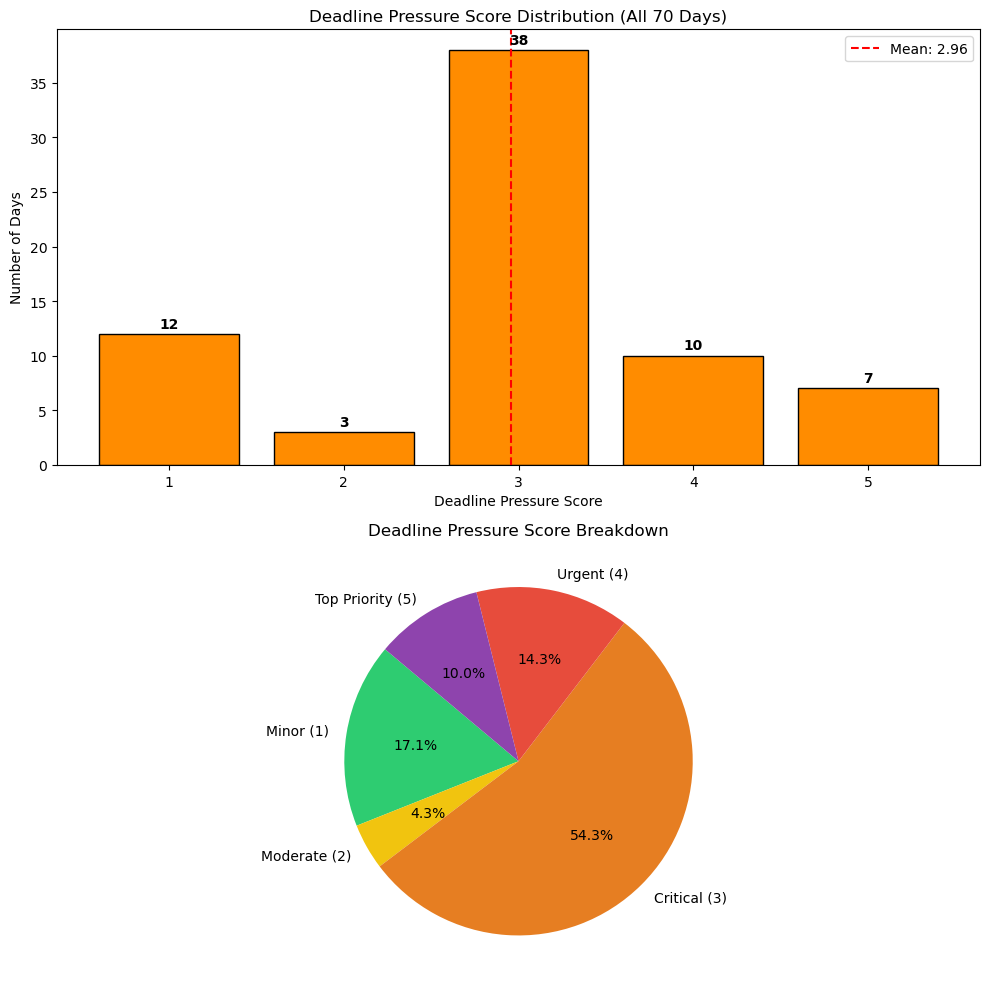

Deadline Pressure Stats:
count    70.000
mean      2.957
std       1.135
min       1.000
25%       3.000
50%       3.000
75%       3.000
max       5.000
Name: Other_Deadlines_Present, dtype: float64

Days at Critical or above (≥3): 55/70
Days at Urgent or above   (≥4): 17/70


In [215]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

labels = ['Minor (1)', 'Moderate (2)', 'Critical (3)', 'Urgent (4)', 'Top Priority (5)']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

# Left: Histogram of deadline pressure scores
deadline_counts = df['Other_Deadlines_Present'].value_counts().sort_index()

axes[0].bar(deadline_counts.index, deadline_counts.values,
            color='darkorange', edgecolor='black')

for bar, count in zip(axes[0].patches, deadline_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(count), ha='center', va='bottom', fontweight='bold')

axes[0].set_title('Deadline Pressure Score Distribution (All 70 Days)')
axes[0].set_xlabel('Deadline Pressure Score')
axes[0].set_ylabel('Number of Days')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].axvline(df['Other_Deadlines_Present'].mean(), color='red',
                linestyle='--', linewidth=1.5,
                label=f"Mean: {df['Other_Deadlines_Present'].mean():.2f}")
axes[0].legend()

# Right: Pie chart of score groupings
axes[1].pie(deadline_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=140)
axes[1].set_title('Deadline Pressure Score Breakdown')

plt.tight_layout()
plt.show()

print("Deadline Pressure Stats:")
print(df['Other_Deadlines_Present'].describe().round(3))
print(f"\nDays at Critical or above (≥3): {(df['Other_Deadlines_Present'] >= 3).sum()}/{len(df)}")
print(f"Days at Urgent or above   (≥4): {(df['Other_Deadlines_Present'] >= 4).sum()}/{len(df)}")

#### Interpretation

Score `2` (Moderate) appeared only thrice across 70 days. **INC** subjects (Thesis, Data Science) maintained a chronic baseline of Critical (3) throughout the study period, leaving insufficient low-pressure days to detect a clean displacement effect for H3.

## Caffeine Intake Over Time

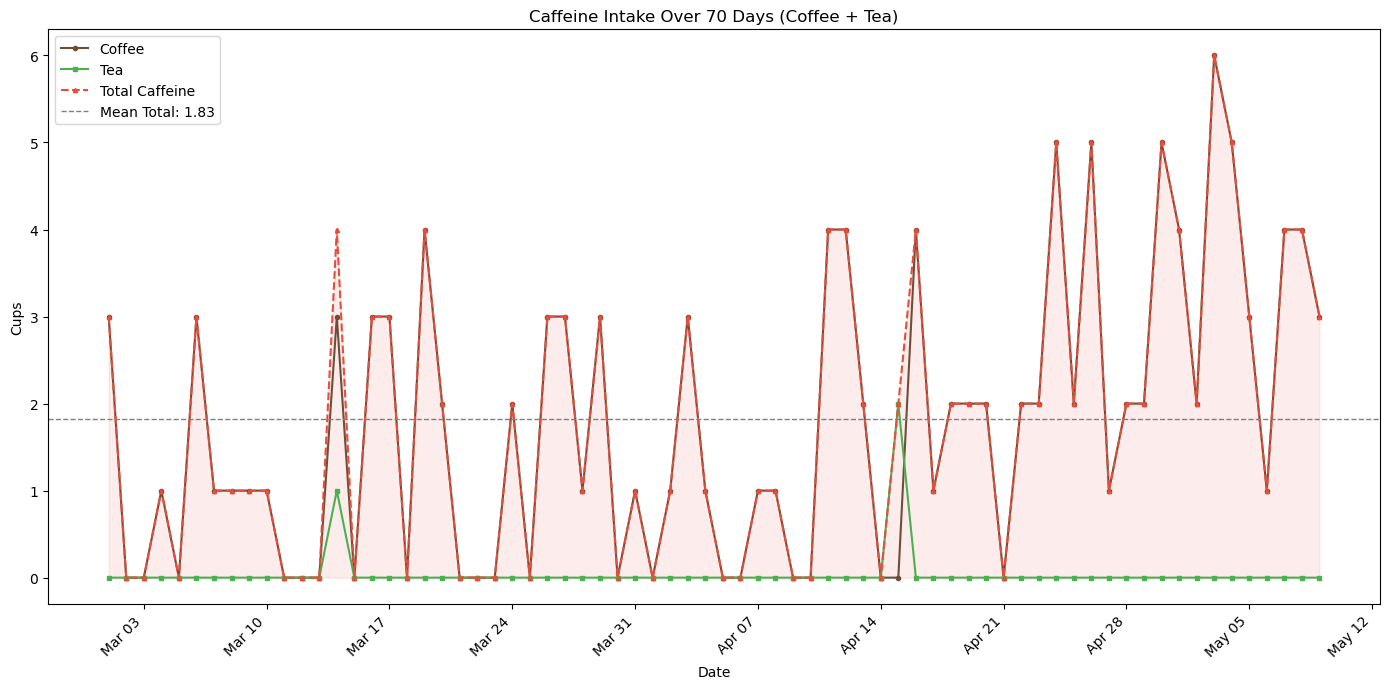

In [216]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df['Date'], df['Coffee_Intake'], color='#6f4e37',
        linewidth=1.5, marker='o', markersize=3, label='Coffee')
ax.plot(df['Date'], df['Tea_Intake'], color='#4caf50',
        linewidth=1.5, marker='s', markersize=3, label='Tea')
ax.plot(df['Date'], df['Total_Caffeine'], color='#e74c3c',
        linewidth=1.5, marker='^', markersize=3, label='Total Caffeine', linestyle='--')

ax.fill_between(df['Date'], df['Total_Caffeine'], alpha=0.1, color='#e74c3c')

# Mean line
ax.axhline(df['Total_Caffeine'].mean(), color='gray', linestyle='--',
           linewidth=1, label=f"Mean Total: {df['Total_Caffeine'].mean():.2f}")

ax.set_title('Caffeine Intake Over 70 Days (Coffee + Tea)')
ax.set_xlabel('Date')
ax.set_ylabel('Cups')
ax.legend()

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Psychological Ratings Over Time

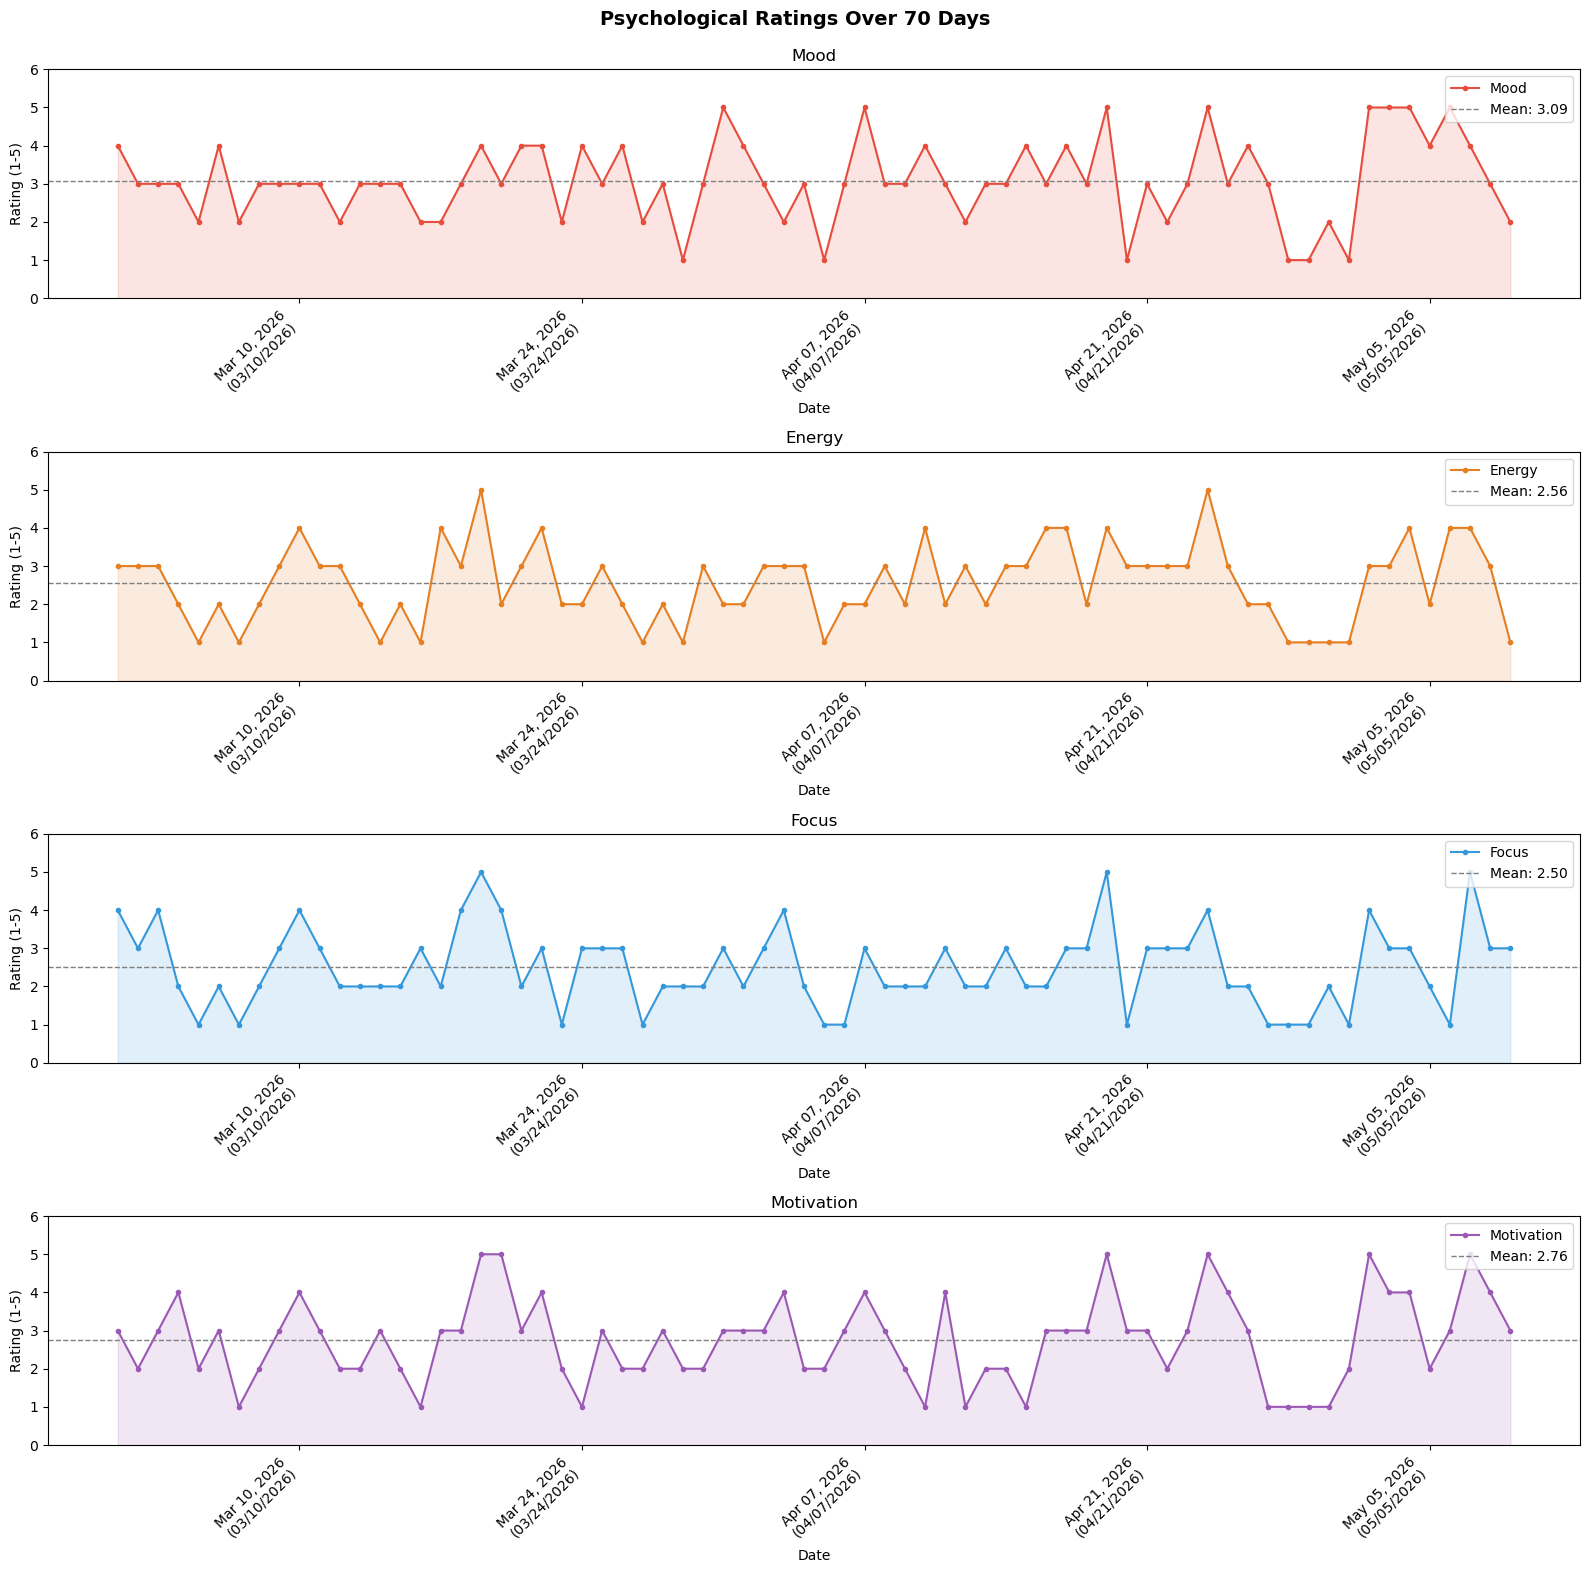

Psychological Ratings Summary:
  Mood         — Mean: 3.086, Min: 1, Max: 5, Std: 1.087
  Energy       — Mean: 2.557, Min: 1, Max: 5, Std: 1.030
  Focus        — Mean: 2.500, Min: 1, Max: 5, Std: 1.046
  Motivation   — Mean: 2.757, Min: 1, Max: 5, Std: 1.135


In [217]:
fig, axes = plt.subplots(4, 1, figsize=(16, 16))

ratings = {
    'Mood_Rating': ('Mood', '#e74c3c', axes[0]),
    'Energy_Level': ('Energy', '#e67e22', axes[1]),
    'Focus_Quality': ('Focus', '#3498db', axes[2]),
    'Motivation_Level': ('Motivation', '#9b59b6', axes[3])
}

for col, (label, color, ax) in ratings.items():
    ax.plot(df['Date'], df[col], color=color,
            linewidth=1.5, marker='o', markersize=3, label=label)
    ax.fill_between(df['Date'], df[col], alpha=0.15, color=color)
    ax.axhline(df[col].mean(), color='gray', linestyle='--',
               linewidth=1, label=f'Mean: {df[col].mean():.2f}')
    ax.set_title(f'{label}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Rating (1-5)')
    ax.set_ylim(0, 6)
    ax.legend(loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y\n(%m/%d/%Y)'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Psychological Ratings Over 70 Days\n', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Psychological Ratings Summary:")
for col, (label, _, _) in ratings.items():
    print(f"  {label:12} — Mean: {df[col].mean():.3f}, "
          f"Min: {df[col].min()}, Max: {df[col].max()}, "
          f"Std: {df[col].std():.3f}")

## Day of Week Pattern

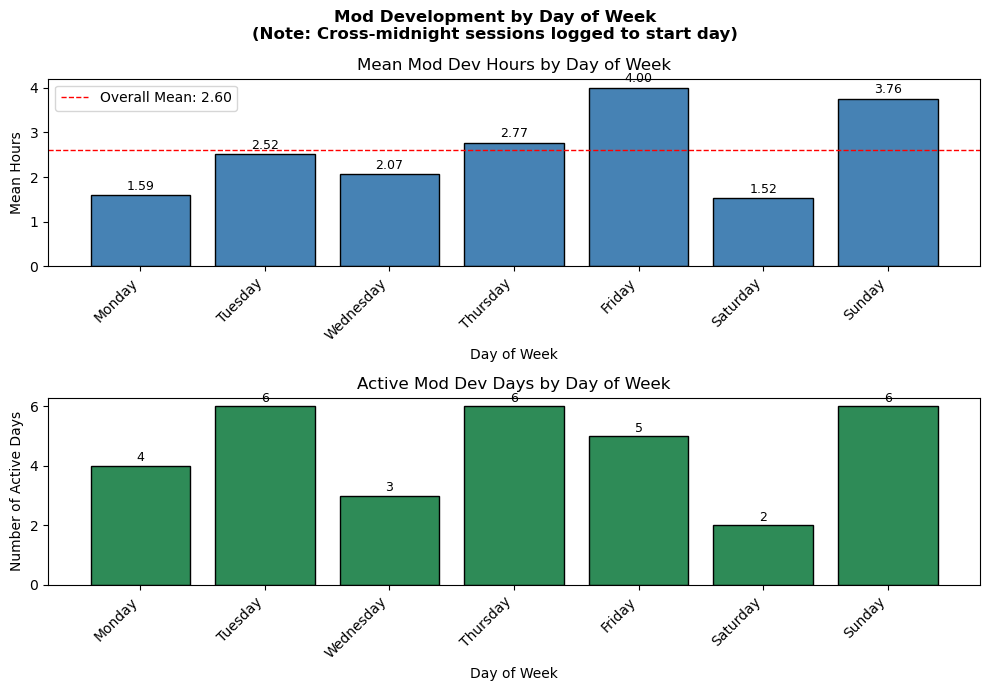

Day of Week Stats:
              mean     sum  count
Day_Of_Week                      
Monday       1.587  15.867     10
Tuesday      2.517  25.166     10
Wednesday    2.068  20.683     10
Thursday     2.772  27.717     10
Friday       4.004  40.035     10
Saturday     1.520  15.200     10
Sunday       3.758  37.582     10


In [218]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_stats = df.groupby('Day_Of_Week')['Mod_Development_Hours'].agg(['mean', 'sum', 'count'])
day_stats = day_stats.reindex(day_order)

fig, axes = plt.subplots(2, 1, figsize=(10, 7))

# Left: Mean mod dev hours per day of week
bars = axes[0].bar(day_stats.index, day_stats['mean'],
                   color='steelblue', edgecolor='black')

for bar, val in zip(bars, day_stats['mean']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', va='bottom', fontsize=9)

axes[0].set_title('Mean Mod Dev Hours by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Mean Hours')
axes[0].axhline(df['Mod_Development_Hours'].mean(), color='red',
                linestyle='--', linewidth=1,
                label=f'Overall Mean: {df["Mod_Development_Hours"].mean():.2f}')
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Right: Count of active days per day of week
active_day_counts = df[df['Mod_Development_Hours'] > 0].groupby('Day_Of_Week').size().reindex(day_order, fill_value=0)

bars2 = axes[1].bar(active_day_counts.index, active_day_counts.values,
                    color='seagreen', edgecolor='black')

for bar, val in zip(bars2, active_day_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 str(val), ha='center', va='bottom', fontsize=9)

axes[1].set_title('Active Mod Dev Days by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Active Days')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.suptitle('Mod Development by Day of Week\n(Note: Cross-midnight sessions logged to start day)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Day of Week Stats:")
print(day_stats.round(3))

### Interpretation

Friday and Sunday show highest mean hours, reflecting post-obligation freedom windows in the weekly schedule. Saturday and Monday show lowest activity, consistent with F2F class fatigue and subsequent recovery respectively. Cross-midnight sessions further compress Saturday counts as late Sunday sessions log to Sunday, not Saturday.

Aligning it with the subject's weekly schedule, it does make sense as:
- **Sunday**: The rest day after a mostly face-to-face class from Saturday (see Saturday entry). This is the most free the subject is free from academic and work obligations allowing him to either do more work or rest. When the subject decides to work on the mod development, he frequently extends past midnight into Monday's early morning.
- **Monday**: Feeling nauseous and sick after overextending mod development from Sunday evening. This leaves the subject unable to ride his bicycle to work.
- **Tuesday**: Usually the day when the subject goes to the office to handle some office-related works or for his Internship subject. If not, usually locked in on doing dailies while planning for the week's schedule.
- **Wednesday**: Online classes begins on 11 AM and usually ends around 1 PM. The rest of the time (1 PM to 3 PM) are usually reserved on working with an assigned Lab or Problem Set task leaving the night for daily game checks. This usually extends until the early morning of the following day.
- **Thursday**: Another day which the subject usually goes to the office for the same agenda as from the Tuesday entry. When not, the daily game check is done early and by evening, begins working on the mod development.
- **Friday**: The mod development on the day before almost always overextend to this day's morning, resulting to a very high mod hour mean. With the subject also almost always alone during this day, he can start and focus more on the development than being interrupted.
- **Saturday**: Another class day. Usually a face-to-face class requiring the subject to prepare at 7 AM and must leave the house before 8 AM to account for a potential three (3) hour commute to the school. Classes starts at 11 AM and usually ends at around 1 PM to 1:30 PM, rarely ever reaching 2 to 3 PM. The commute back takes 2 to 3 hours as well leaving the subject exhausted by the time he reaches house. This leaves the subject unable to do any mod work as the daily game check takes up the remaining time before falling asleep early or literally after the checks.

# Statistical Testing

This section has four parts corresponding to the three hypotheses. It was broken down like this to test the hypoptheses and create a conclusion.

## (H1) Caffeine vs Productivity (Pearson Correlation)

In this hypotheses, we expect that despite the high caffeine tolerance from years of intensive work, regulated caffeine intake will show no significant correlation with productivity metrics, demonstrating that caffeine's effectiveness diminishes with habitual use.

### All Days

In [219]:
print("=" * 60)
print("H1: Caffeine Intake vs Mod Development Productivity")
print("=" * 60)

r, p = stats.pearsonr(df['Total_Caffeine_mL'], df['Mod_Development_Hours'])

print(f"\nPearson Correlation:")
print(f"  r = {r:.4f}")
print(f"  p = {p:.4f}")
print(f"\nConclusion:")
if p < 0.05:
    print(f"  REJECT H0 — Significant correlation found (r={r:.4f})")
else:
    print(f"  FAIL TO REJECT H0 — No significant correlation (r={r:.4f})")
    print(f"  Consistent with high caffeine tolerance and deliberate")
    print(f"  reduction during the study period.")

H1: Caffeine Intake vs Mod Development Productivity

Pearson Correlation:
  r = 0.4158
  p = 0.0003

Conclusion:
  REJECT H0 — Significant correlation found (r=0.4158)


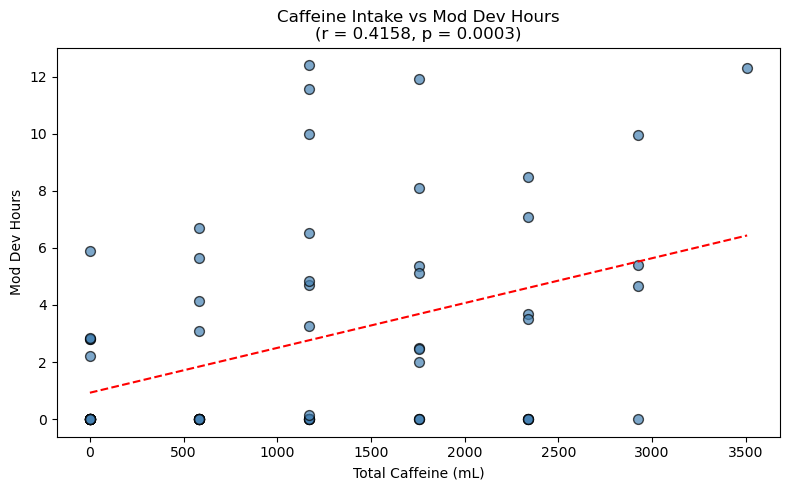

In [220]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df['Total_Caffeine_mL'], df['Mod_Development_Hours'],
           color='steelblue', edgecolor='black', alpha=0.7, s=50)

# Regression line
m, b = np.polyfit(df['Total_Caffeine_mL'], df['Mod_Development_Hours'], 1)
x_line = np.linspace(df['Total_Caffeine_mL'].min(), df['Total_Caffeine_mL'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--')

ax.set_title(f'Caffeine Intake vs Mod Dev Hours\n(r = {r:.4f}, p = {p:.4f})')
ax.set_xlabel('Total Caffeine (mL)')
ax.set_ylabel('Mod Dev Hours')

plt.tight_layout()
plt.show()

### Active Days Only

In [221]:
print("H1 Re-analysis: Active Days Only (n=32)")
print("=" * 60)

active_df = df[df['Mod_Development_Hours'] > 0]

r_active, p_active = stats.pearsonr(
    active_df['Total_Caffeine_mL'],
    active_df['Mod_Development_Hours']
)

print(f"\nPearson Correlation (active days only):")
print(f"  r = {r_active:.4f}")
print(f"  p = {p_active:.4f}")
print(f"\nConclusion:")
if p_active < 0.05:
    print(f"  REJECT H0 — Significant correlation found (r={r_active:.4f})")
else:
    print(f"  FAIL TO REJECT H0 — No significant correlation (r={r_active:.4f})")
    print(f"  Consistent with high caffeine tolerance hypothesis.")

H1 Re-analysis: Active Days Only (n=32)

Pearson Correlation (active days only):
  r = 0.3521
  p = 0.0481

Conclusion:
  REJECT H0 — Significant correlation found (r=0.3521)


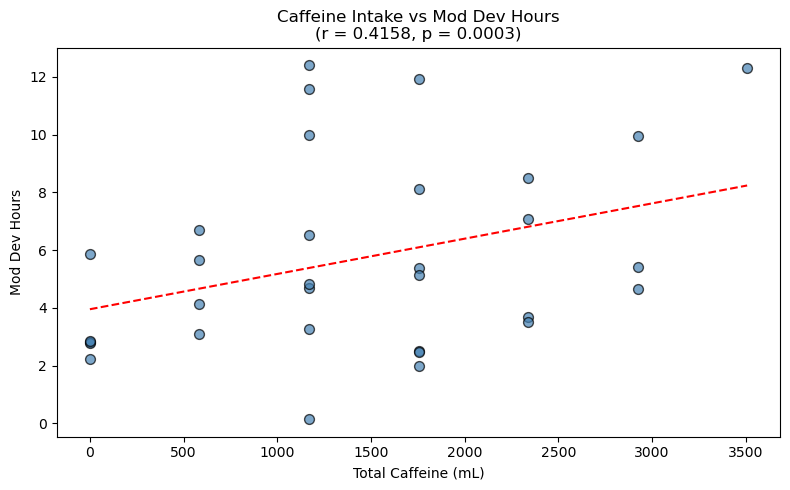

In [222]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(active_df['Total_Caffeine_mL'], active_df['Mod_Development_Hours'],
           color='steelblue', edgecolor='black', alpha=0.7, s=50)

# Regression line
m, b = np.polyfit(active_df['Total_Caffeine_mL'], active_df['Mod_Development_Hours'], 1)
x_line = np.linspace(active_df['Total_Caffeine_mL'].min(), active_df['Total_Caffeine_mL'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--')

ax.set_title(f'Caffeine Intake vs Mod Dev Hours\n(r = {r:.4f}, p = {p:.4f})')
ax.set_xlabel('Total Caffeine (mL)')
ax.set_ylabel('Mod Dev Hours')

plt.tight_layout()
plt.show()

### Interpretation

The positive correlation (r=0.35, p=0.048) is marginally significant but likely reflects a common-cause relationship: planned productive sessions drive both higher caffeine consumption and higher mod dev hours simultaneously. Caffeine causing productivity cannot be established from this observational design. The deliberate reduction in caffeine intake during the study period further confounds direct causal interpretation.

While there are evidence of correlation between the two, it is worth noting that caffeine intake was recorded as a **daily total** rather than **session-specific consumption**, meaning it captures drinks consumed during office work, daily routines, and gaming sessions — not exclusively during mod development. This measurement granularity limits the interpretability of any observed correlation between caffeine intake and mod development productivity.

## (H2) Night vs Day Sessions — Independent t-test

In this hypotheses, we expected that late-night work sessions (7PM-7AM) to consistently outperform daytime sessions due to the absence of household interruptions that fragment my focus during conventional work hours, challenging productivity advice that prioritizes morning work without accounting for individual environmental constraints and chronotype.

In [223]:
print("=" * 60)
print("H2: Night vs Day Session Productivity")
print("=" * 60)

active_df = df[df['Mod_Development_Hours'] > 0]

night_sessions = active_df[active_df['Is_Night_Session'] == True]['Mod_Development_Hours']
day_sessions = active_df[active_df['Is_Night_Session'] == False]['Mod_Development_Hours']

print(f"\nNight Sessions (n={len(night_sessions)}):")
print(f"  Mean: {night_sessions.mean():.4f} hrs")
print(f"  Std:  {night_sessions.std():.4f} hrs")
print(f"\nDay Sessions (n={len(day_sessions)}):")
print(f"  Mean: {day_sessions.mean():.4f} hrs")
print(f"  Std:  {day_sessions.std():.4f} hrs")

t_stat, p_two = stats.ttest_ind(night_sessions, day_sessions)
p_one = p_two / 2

print(f"\nIndependent t-test (one-tailed):")
print(f"  t = {t_stat:.4f}")
print(f"  p (two-tailed) = {p_two:.4f}")
print(f"  p (one-tailed) = {p_one:.4f}")
print(f"\nConclusion:")
if p_one < 0.05 and night_sessions.mean() > day_sessions.mean():
    print(f"  REJECT H0 — Night sessions significantly more productive")
else:
    print(f"  FAIL TO REJECT H0 — No significant difference found")
    print(f"  Note: Day session sample (n={len(day_sessions)}) is very small,")
    print(f"  limiting statistical power of this test.")

H2: Night vs Day Session Productivity

Night Sessions (n=28):
  Mean: 5.5321 hrs
  Std:  3.3595 hrs

Day Sessions (n=4):
  Mean: 6.8376 hrs
  Std:  3.3934 hrs

Independent t-test (one-tailed):
  t = -0.7262
  p (two-tailed) = 0.4733
  p (one-tailed) = 0.2367

Conclusion:
  FAIL TO REJECT H0 — No significant difference found
  Note: Day session sample (n=4) is very small,
  limiting statistical power of this test.


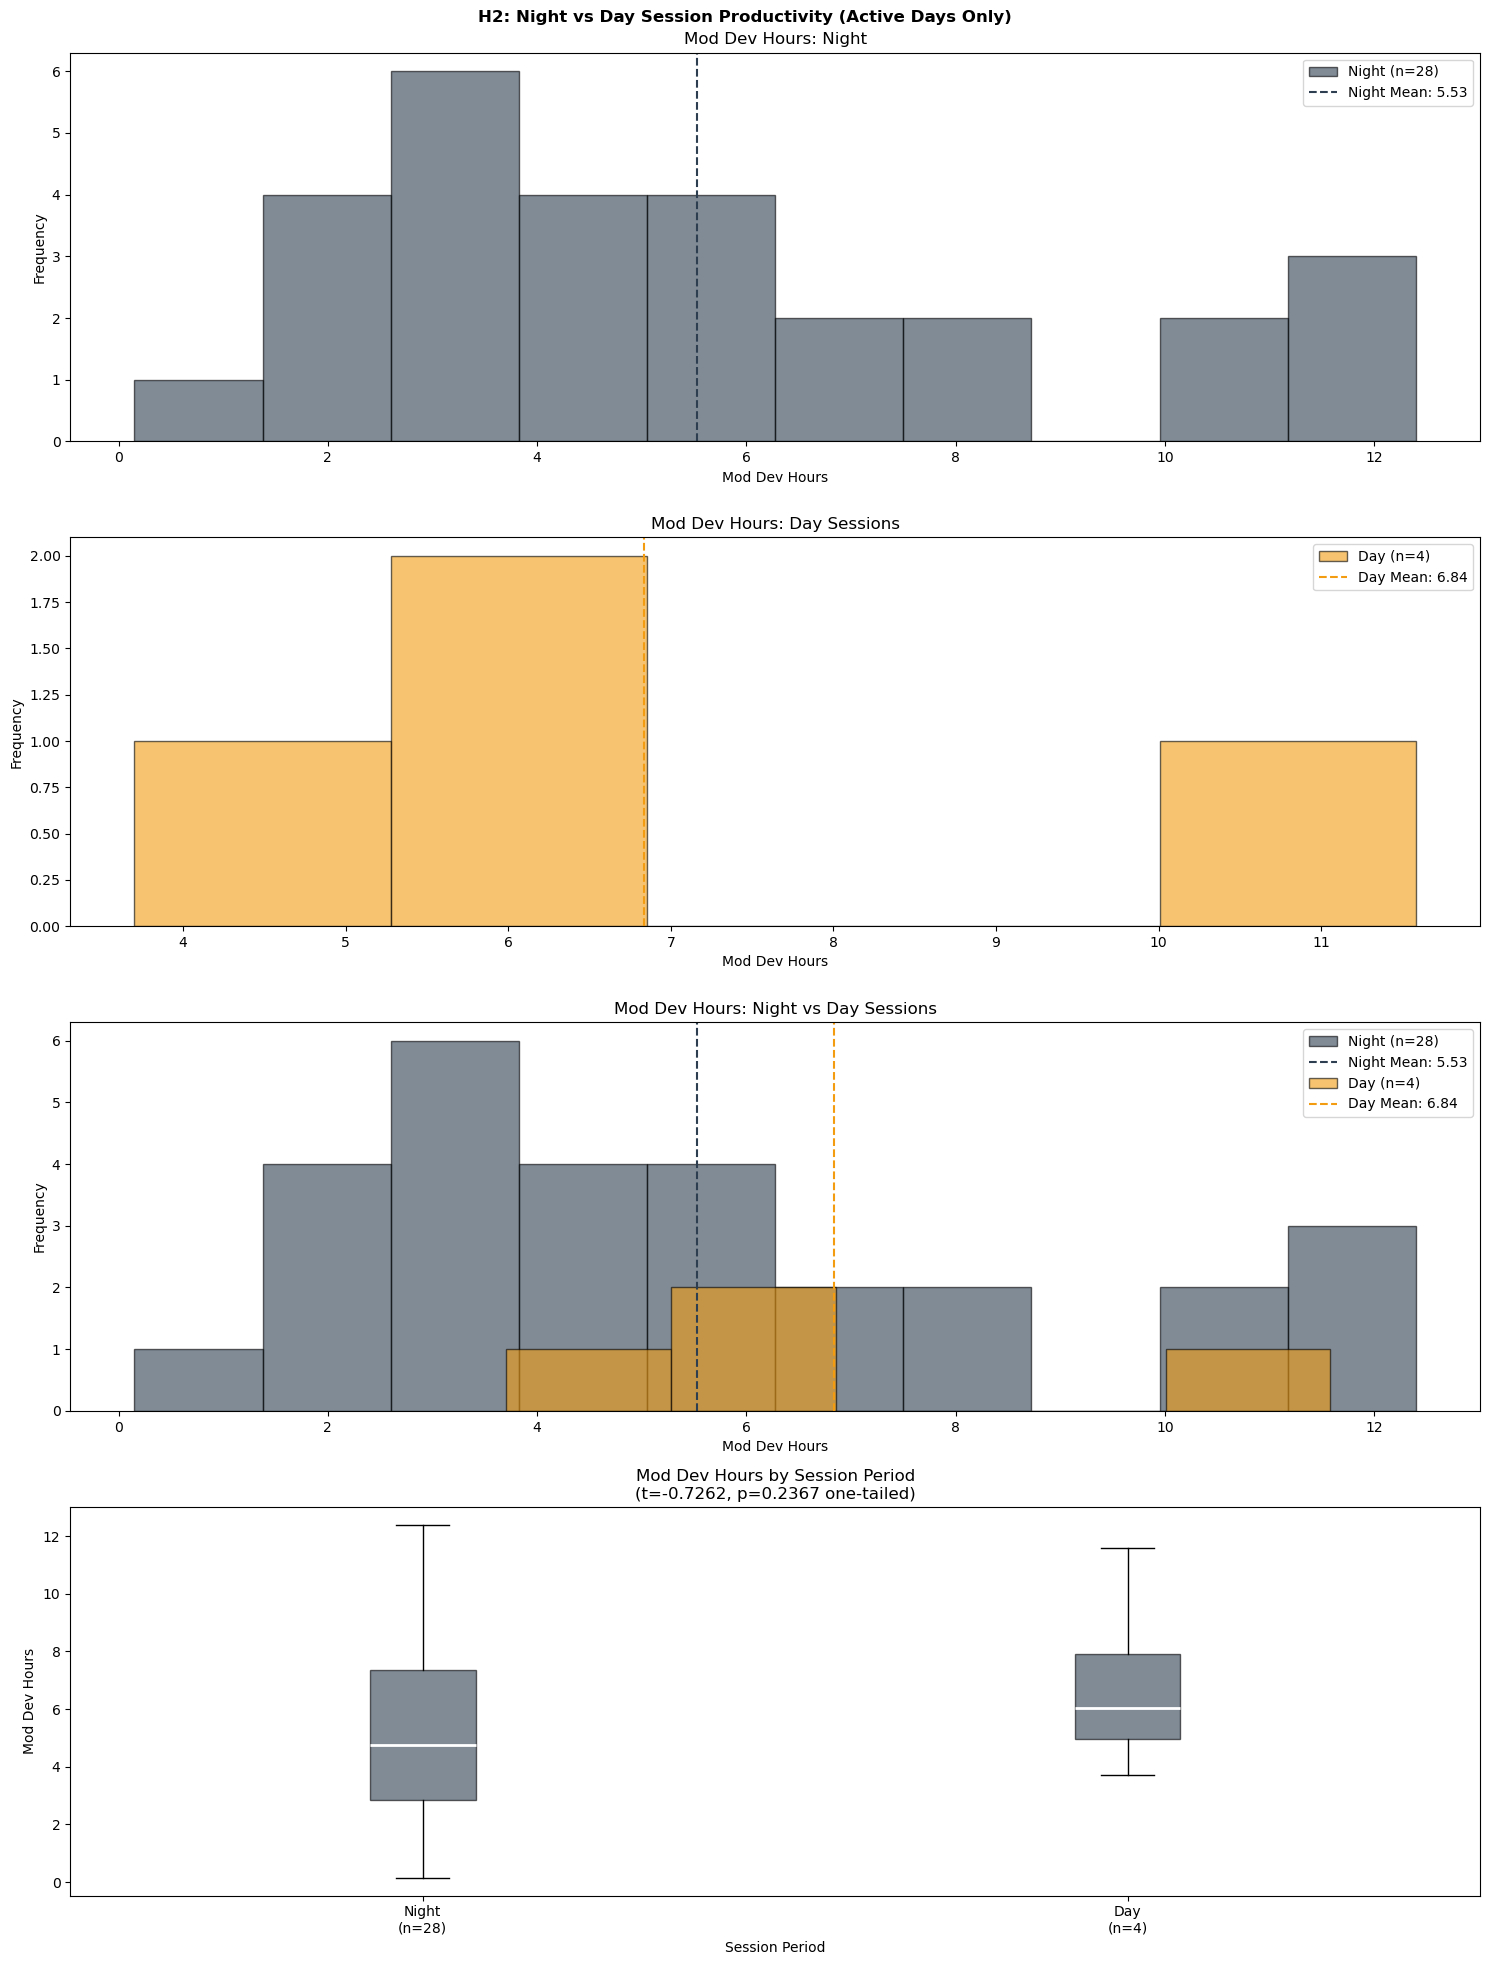

In [224]:
fig, axes = plt.subplots(4, 1, figsize=(15, 20))

# Top: Night Distribution comparison
axes[0].hist(
    night_sessions, bins=10, alpha=0.6,
    color='#2c3e50', edgecolor='black',
    label=f'Night (n={len(night_sessions)})'
)
axes[0].axvline(
    night_sessions.mean(), color='#2c3e50',
    linestyle='--', linewidth=1.5,
    label=f'Night Mean: {night_sessions.mean():.2f}'
)

axes[0].set_title('Mod Dev Hours: Night')
axes[0].set_xlabel('Mod Dev Hours')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Middle Top: Day Distribution comparison
axes[1].hist(
    day_sessions, bins=5, alpha=0.6,
    color='#f39c12', edgecolor='black',
    label=f'Day (n={len(day_sessions)})'
)
axes[1].axvline(
    day_sessions.mean(), color='#f39c12',
    linestyle='--', linewidth=1.5,
    label=f'Day Mean: {day_sessions.mean():.2f}'
)

axes[1].set_title('Mod Dev Hours: Day Sessions')
axes[1].set_xlabel('Mod Dev Hours')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# Middle Bottom: Combined Day & Night Distribution comparison
axes[2].hist(
    night_sessions, bins=10, alpha=0.6,
    color='#2c3e50', edgecolor='black',
    label=f'Night (n={len(night_sessions)})'
)
axes[2].axvline(
    night_sessions.mean(), color='#2c3e50',
    linestyle='--', linewidth=1.5,
    label=f'Night Mean: {night_sessions.mean():.2f}'
)
axes[2].hist(
    day_sessions, bins=5, alpha=0.6,
    color='#f39c12', edgecolor='black',
    label=f'Day (n={len(day_sessions)})'
)
axes[2].axvline(
    day_sessions.mean(), color='#f39c12',
    linestyle='--', linewidth=1.5,
    label=f'Day Mean: {day_sessions.mean():.2f}'
)

axes[2].set_title('Mod Dev Hours: Night vs Day Sessions')
axes[2].set_xlabel('Mod Dev Hours')
axes[2].set_ylabel('Frequency')
axes[2].legend()

# Bottom: Box plot
axes[3].boxplot(
    [night_sessions, day_sessions],
    tick_labels=[f'Night\n(n={len(night_sessions)})', f'Day\n(n={len(day_sessions)})'],
    patch_artist=True,
    boxprops=dict(facecolor='#2c3e50', alpha=0.6),
    medianprops=dict(color='white', linewidth=2)
)

axes[3].set_title(f'Mod Dev Hours by Session Period\n(t={t_stat:.4f}, p={p_one:.4f} one-tailed)')
axes[3].set_xlabel('Session Period')
axes[3].set_ylabel('Mod Dev Hours')

plt.suptitle('H2: Night vs Day Session Productivity (Active Days Only)\n', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation

H2 is not supported — Day sessions averaged higher hours (6.84 hrs) than Night sessions (5.53 hrs), contradicting the hypothesis that night sessions are more productive. However, this result must be interpreted with extreme caution due to the following reasons:

- **Sample imbalance:** Day sessions (n=4, 12.5%) vs Night sessions (n=28, 87.5%) of active days
- **No statistical significance:** p=0.2367 is well above the α=0.05 threshold
- **Questionable Day group validity:** The 4 day sessions likely represent cross-midnight sessions from the previous evening bleeding into morning hours rather than genuinely daytime-initiated sessions — which would explain their unexpectedly high hour counts

The subject's chronotype is so consistently nocturnal that an adequate Day session comparison group does not exist in this dataset. H2 cannot be properly evaluated with this dataset due to insufficient day session observations. A study with deliberately structured daytime sessions would be required to meaningfully test this hypothesis.

## (H3) Deadline Pressure vs Mod Development Hours

In [225]:
print("=" * 60)
print("H3: Deadline Pressure vs Mod Development Productivity")
print("=" * 60)

r_h3, p_h3 = stats.pearsonr(df['Other_Deadlines_Present'],
                              df['Mod_Development_Hours'])

print(f"\nPearson Correlation (all 70 days):")
print(f"  r = {r_h3:.4f}")
print(f"  p = {p_h3:.4f}")
print(f"\nConclusion:")
if p_h3 < 0.05 and r_h3 < 0:
    print(f"  REJECT H0 — Significant negative correlation found")
    print(f"  Deadline pressure displaces mod development hours.")
else:
    print(f"  FAIL TO REJECT H0 — No significant negative correlation")
    print(f"  Note: Low variance in deadline scores (chronic Critical")
    print(f"  baseline) limits detection of displacement effect.")

H3: Deadline Pressure vs Mod Development Productivity

Pearson Correlation (all 70 days):
  r = -0.1942
  p = 0.1073

Conclusion:
  FAIL TO REJECT H0 — No significant negative correlation
  Note: Low variance in deadline scores (chronic Critical
  baseline) limits detection of displacement effect.


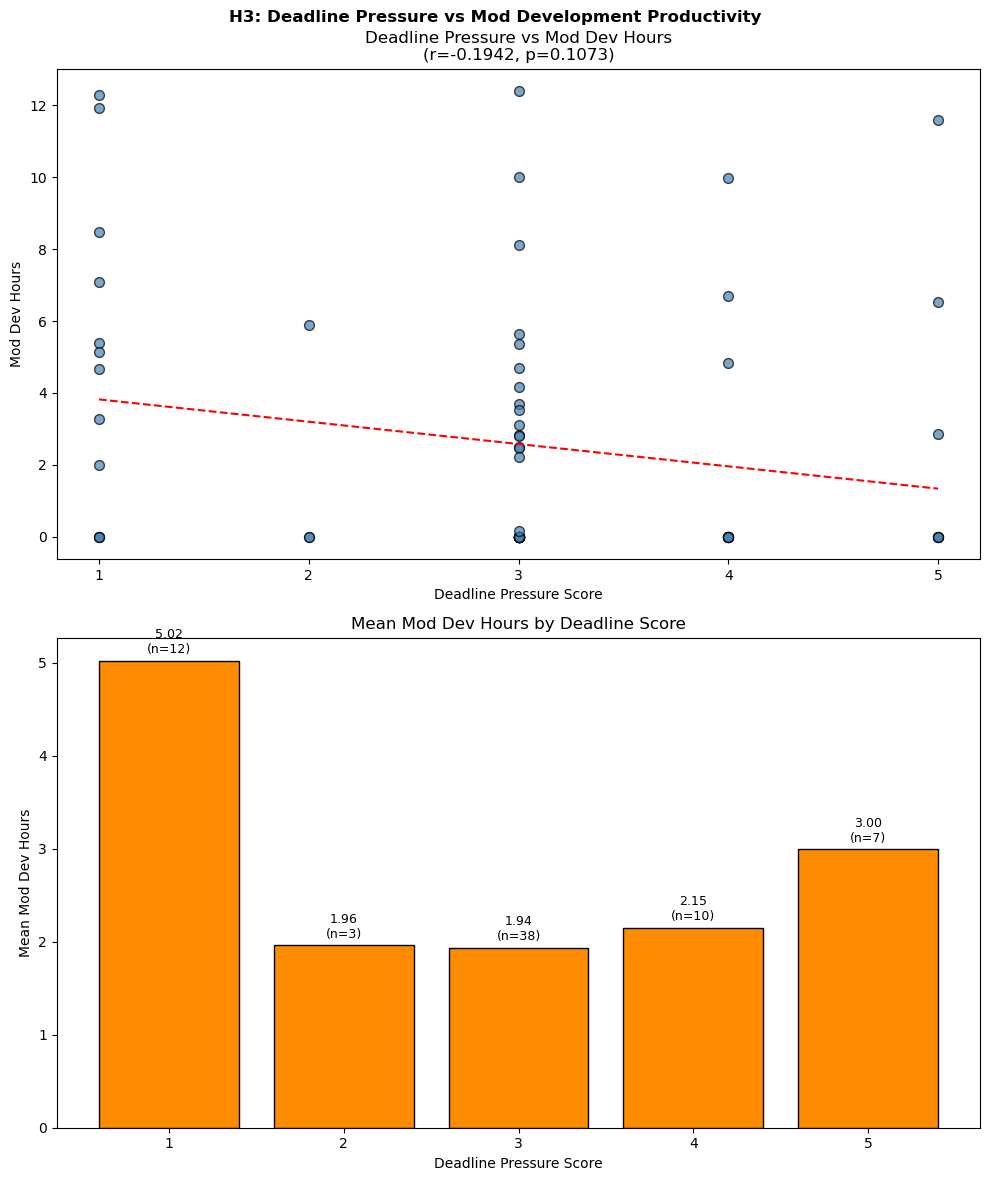

In [226]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Top: Scatter plot
axes[0].scatter(df['Other_Deadlines_Present'], df['Mod_Development_Hours'],
                color='steelblue', edgecolor='black', alpha=0.7, s=50)

m, b = np.polyfit(df['Other_Deadlines_Present'], df['Mod_Development_Hours'], 1)
x_line = np.linspace(df['Other_Deadlines_Present'].min(),
                     df['Other_Deadlines_Present'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red',
             linewidth=1.5, linestyle='--')

axes[0].set_title(f'Deadline Pressure vs Mod Dev Hours\n(r={r_h3:.4f}, p={p_h3:.4f})')
axes[0].set_xlabel('Deadline Pressure Score')
axes[0].set_ylabel('Mod Dev Hours')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Bottom: Mean mod dev hours per deadline score
deadline_productivity = df.groupby('Other_Deadlines_Present')['Mod_Development_Hours'].agg(['mean', 'count'])

bars = axes[1].bar(deadline_productivity.index, deadline_productivity['mean'],
                   color='darkorange', edgecolor='black')

for bar, (idx, row) in zip(bars, deadline_productivity.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{row['mean']:.2f}\n(n={int(row['count'])})",
                 ha='center', va='bottom', fontsize=9)

axes[1].set_title('Mean Mod Dev Hours by Deadline Score')
axes[1].set_xlabel('Deadline Pressure Score')
axes[1].set_ylabel('Mean Mod Dev Hours')
axes[1].set_xticks([1, 2, 3, 4, 5])

plt.suptitle('H3: Deadline Pressure vs Mod Development Productivity',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation

H3 is not supported — the negative correlation between deadline pressure 
and mod development hours (r=-0.1942, p=0.1073) did not reach statistical 
significance. However, the directional trend is consistent with the 
displacement hypothesis, and the mean hours by deadline score reveals 
a nuanced pattern:

- **Score 1 (Minor):** Highest mean output (5.02 hrs, n=12), confirming 
  that low-pressure days are the most productive for mod development.
- **Scores 2–4:** Mean hours collapse to ~1.94–2.15 hrs, suggesting a 
  productivity floor once deadline pressure reaches Moderate or above.
- **Score 5 (Top Priority):** Unexpected uptick (3.00 hrs, n=7), likely 
  reflecting an escapism or displacement-reversal effect — on days where 
  institutional obligations (thesis, academic requirements, professional 
  documentation) reached maximum urgency, voluntary mod development served 
  as a psychological retreat, paradoxically sustaining output despite 
  peak external pressure.

The absence of statistical significance is largely attributable to the 
chronic Critical baseline (Score 3 = 54.3% of all days) leaving insufficient 
low-pressure observations to detect a clean displacement effect. The 
displacement pattern is visible descriptively but unprovable statistically 
given the dataset's constraint.

# Correlation Matrix

CORRELATION MATRIX


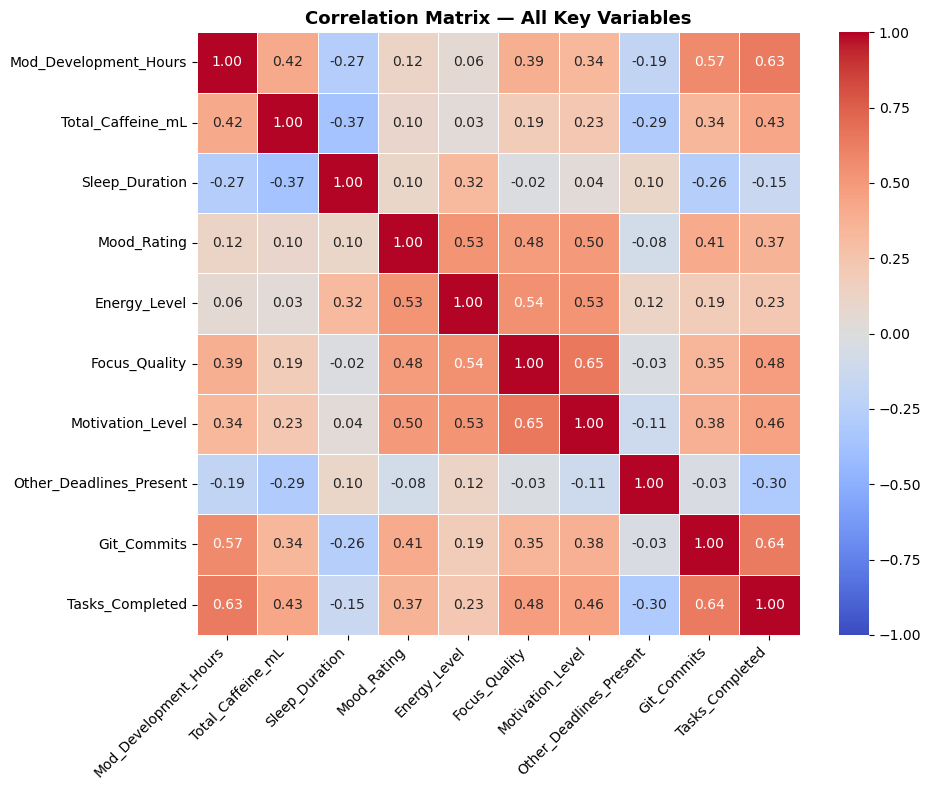


Correlations with Mod_Development_Hours:
Tasks_Completed            0.6333
Git_Commits                0.5750
Total_Caffeine_mL          0.4158
Focus_Quality              0.3873
Motivation_Level           0.3353
Mood_Rating                0.1221
Energy_Level               0.0559
Other_Deadlines_Present   -0.1942
Sleep_Duration            -0.2660
Name: Mod_Development_Hours, dtype: float64


In [227]:
print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

corr_cols = [
    'Mod_Development_Hours',
    'Total_Caffeine_mL',
    'Sleep_Duration',
    'Mood_Rating',
    'Energy_Level',
    'Focus_Quality',
    'Motivation_Level',
    'Other_Deadlines_Present',
    'Git_Commits',
    'Tasks_Completed'
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            ax=ax)

ax.set_title('Correlation Matrix — All Key Variables', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

print("\nCorrelations with Mod_Development_Hours:")
print(corr_matrix['Mod_Development_Hours']
      .drop('Mod_Development_Hours')
      .sort_values(ascending=False)
      .round(4))

## Interpretation

The correlation matrix reveals several key patterns across all variables:

**Productivity Predictors (Mod_Development_Hours):**
- Tasks Completed (r=0.63) and Git Commits (r=0.57) show the strongest 
  correlations, serving as output validation — more hours consistently 
  produced more measurable output, confirming tracking consistency.
- Focus Quality (r=0.39) and Motivation Level (r=0.34) are the strongest 
  psychological predictors of mod dev hours, suggesting that intrinsic 
  drive and cognitive engagement matter more than general mood or energy 
  for deep programming work.
- Mood Rating (r=0.12) and Energy Level (r=0.06) show surprisingly weak 
  correlations, indicating the subject codes productively regardless of 
  general affect or energy state.
- Sleep Duration (r=-0.27) is negative, directly reflecting cross-midnight 
  sessions consuming sleep time — longer sessions mean less sleep, not 
  the other way around.

**Inter-variable Relationships:**
- Focus and Motivation are strongly coupled (r=0.65), suggesting they 
  function as a unified psychological state during development sessions.
- Sleep and Caffeine show a moderate negative correlation (r=-0.37), 
  consistent with compensatory caffeine use following short sleep.
- Tasks Completed and Deadlines Present show a notable negative correlation 
  (r=-0.30), providing indirect support for the H3 displacement effect 
  despite the direct Mod_Dev_Hours correlation failing significance.

# Regression Modeling

In [228]:
print("=" * 60)
print("REGRESSION MODEL: Predicting Mod Development Hours")
print("=" * 60)

# Features and target
features = [
    'Total_Caffeine_mL',
    'Sleep_Duration',
    'Mood_Rating',
    'Energy_Level',
    'Focus_Quality',
    'Motivation_Level',
    'Other_Deadlines_Present'
]

X = df[features]
y = df['Mod_Development_Hours']

# Fit model
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Metrics
r2 = r2_score(y, y_pred)
rmse = mean_squared_error(y, y_pred) ** 0.5

print(f"\nModel Performance:")
print(f"  R² = {r2:.4f}")
print(f"  RMSE = {rmse:.4f} hrs")

print(f"\nFeature Coefficients:")
for feature, coef in sorted(zip(features, model.coef_),
                             key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feature:25} {coef:+.4f}")

print(f"\n  Intercept: {model.intercept_:.4f}")

REGRESSION MODEL: Predicting Mod Development Hours

Model Performance:
  R² = 0.3197
  RMSE = 2.9717 hrs

Feature Coefficients:
  Focus_Quality             +1.1761
  Energy_Level              -0.4995
  Motivation_Level          +0.4978
  Mood_Rating               -0.2169
  Other_Deadlines_Present   -0.2120
  Sleep_Duration            -0.1367
  Total_Caffeine_mL         +0.0010

  Intercept: 0.4689


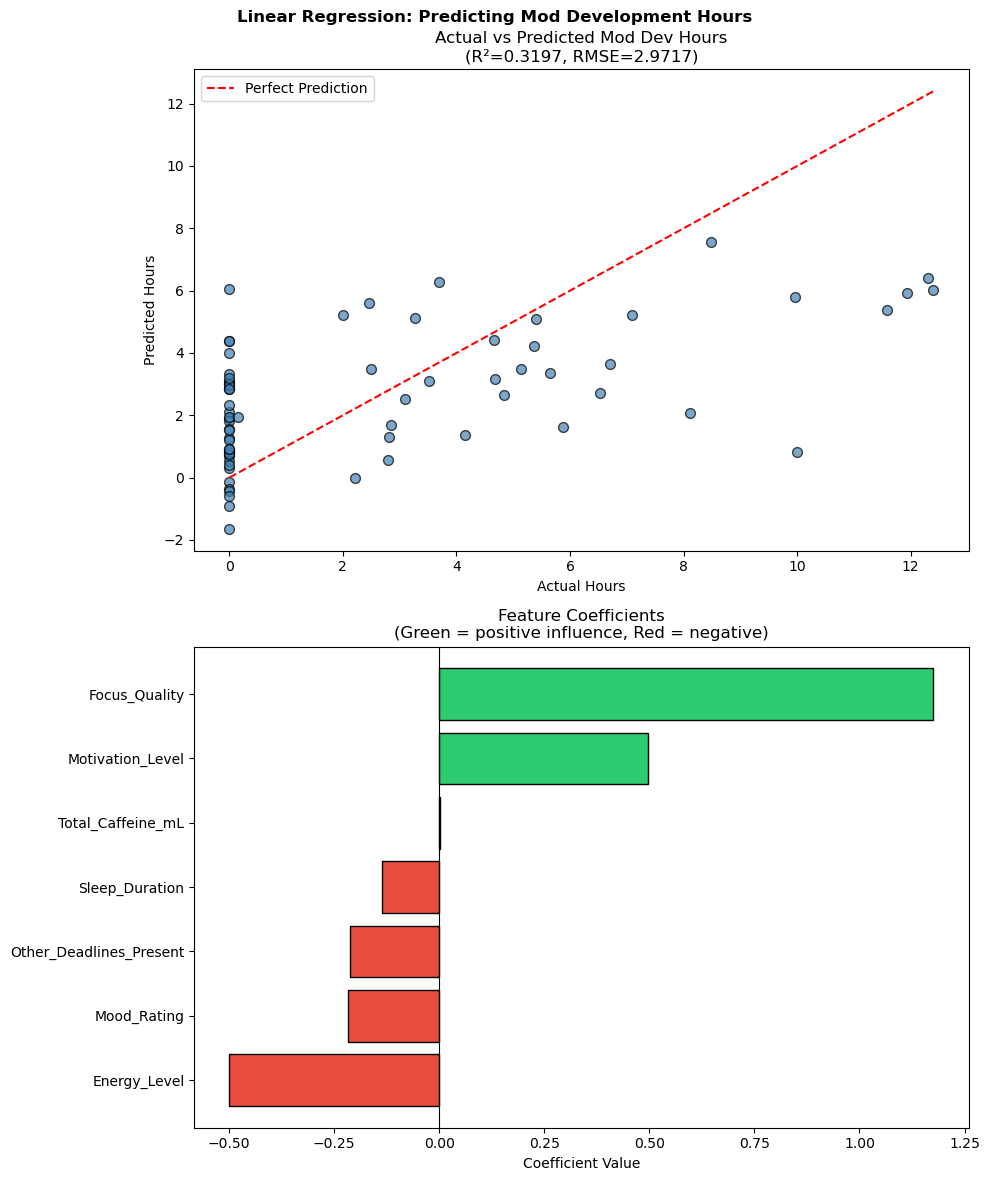

In [229]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Top: Actual vs Predicted
axes[0].scatter(y, y_pred, color='steelblue',
                edgecolor='black', alpha=0.7, s=50)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()],
             color='red', linestyle='--', linewidth=1.5,
             label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted Mod Dev Hours\n(R²={r2:.4f}, RMSE={rmse:.4f})')
axes[0].set_xlabel('Actual Hours')
axes[0].set_ylabel('Predicted Hours')
axes[0].legend()

# Bottom: Feature coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=True)

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Coefficient']]
axes[1].barh(coef_df['Feature'], coef_df['Coefficient'],
             color=colors, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature Coefficients\n(Green = positive influence, Red = negative)')
axes[1].set_xlabel('Coefficient Value')

plt.suptitle('Linear Regression: Predicting Mod Development Hours',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretation

The linear regression model (R²=0.32, RMSE=2.97 hrs) explains approximately 
32% of the variance in daily mod development hours. A reasonable result for 
a single-subject behavioral study where unmeasured factors such as development 
milestones, feature complexity, and intrinsic engagement naturally drive 
substantial unexplained variance.

**Key findings from the model:**

- **Focus Quality (β=+1.18)** emerges as the dominant predictor — the single 
  most actionable lever for mod development productivity. A one-point increase 
  in focus rating is associated with approximately 1.18 additional hours of 
  development output.

- **Motivation Level (β=+0.50)** confirms the intrinsic, passion-driven 
  nature of the work as the second strongest positive predictor.

- **Total Caffeine mL (β=+0.001)** contributes essentially zero predictive 
  value once psychological factors are controlled for, providing the clearest 
  evidence against a direct caffeine-productivity relationship for H1.

- **Energy Level (β=-0.50)** and **Mood Rating (β=-0.22)** show negative 
  coefficients, consistent with the escapism pattern identified earlier — 
  high energy and positive mood are associated with active days outside 
  the home (office, school), while lower energy and mood days are more 
  likely to produce coding sessions as a psychological retreat.

- **Other Deadlines Present (β=-0.21)** maintains a negative direction 
  consistent with H3's displacement hypothesis, though not reaching 
  statistical significance.

The model's intercept of 0.47 hrs suggests a baseline daily output even 
when all predictors are at zero, reflecting the subject's consistent 
baseline engagement with the project throughout the study period.